# 01 — Pré-processamento: Crop + CLAHE

## O que esta fase faz

O Mask R-CNN detecta o hidrômetro na foto. Expandimos o bbox para incluir o visor completo e aplicamos **CLAHE** (contraste adaptativo) para destacar os roletes.

## Por que importa

- Roletes analógicos têm reflexos e baixo contraste
- Crop errado corta dígitos → leitura impossível
- CLAHE melhora legibilidade para o VLM

## Scripts equivalentes

- `scripts/00_calibrate_crop.py` — calibra expansão do bbox
- `scripts/01_generate_crops.py` — gera `data/crops/{train,val,test}/`

In [1]:
from __future__ import annotations
import os, sys
from pathlib import Path

ROOT = next((p for p in [Path.cwd(), Path.cwd().parent] if (p / "src" / "hidrometro").exists()), None)
if ROOT is None:
    raise RuntimeError("Execute a partir de vit-tcc-qlora-hidrometro/ ou notebooks/")
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
from hidrometro.config import load_yaml, resolve_path
from hidrometro.preprocessing.io import imread_unicode

paths = load_yaml("paths.yaml")
crops_dir = resolve_path(paths["output"]["crops"]) / "test"
sample_paths = sorted(crops_dir.glob("*.jpg"))[:6]
print(f"Amostras em {crops_dir}: {len(list(crops_dir.glob('*.jpg')))}")

Amostras em C:\Users\Niccolas\Downloads\TrabalhoDetecaoObjetos\vit-tcc-qlora-hidrometro\data\crops\test: 72


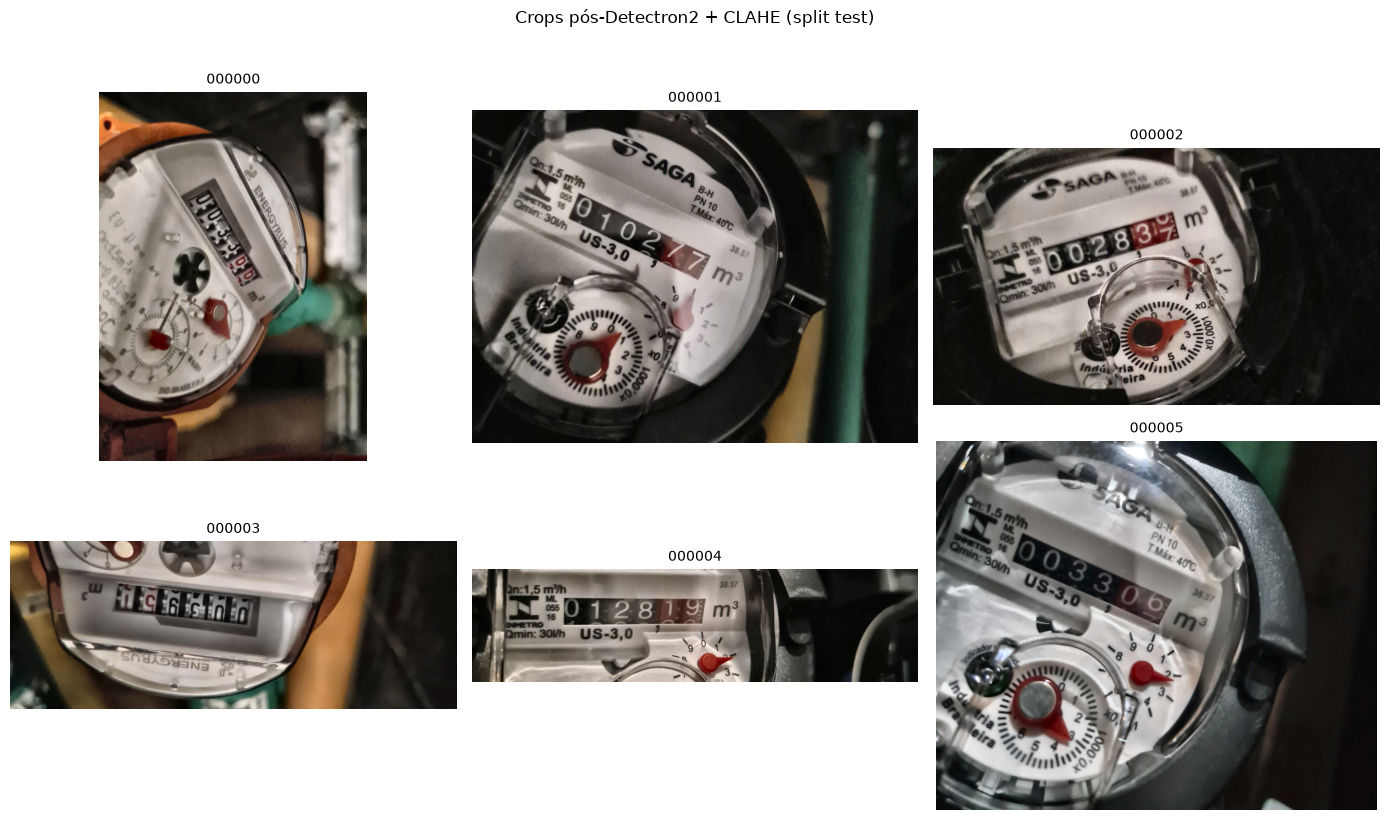

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, p in zip(axes.flat, sample_paths):
    img = imread_unicode(p)
    if img is not None:
        ax.imshow(img[:, :, ::-1])
    ax.set_title(p.stem, fontsize=10)
    ax.axis("off")
plt.suptitle("Crops pós-Detectron2 + CLAHE (split test)", y=1.02)
plt.tight_layout()
plt.show()

## Calibração

Parâmetros de expansão do bbox ficam em `reports/calibration/` após rodar `00_calibrate_crop.py`.

**Próximo notebook:** `02_dataset_e_labels.ipynb` — schema JSON e auditoria dos labels.